In [1]:
# YOLO가 기본적으로 제공하는 COCO 데이터셋 80개 클래스 대신, Aquarium 데이터셋의 7개 클래스를 사용하기 위해 클래스 이름을 정의
# 수족관에 살고 있는 동물 7가지 분류 모델로 finetuing
# roboflow에서 aquarium dataset을 다운로드하여 사용

# 커스텀 데이터에 맞는 yaml(환경 설정 파일) 만들기
import yaml

data = {
    "train": "Aquarium Combined.v2-raw-1024.yolov8//train/images",
    "val": "Aquarium Combined.v2-raw-1024.yolov8//valid/images",
    "test": "Aquarium Combined.v2-raw-1024.yolov8//test/images",

    "nc": 7,
    "names": ['fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']
}

# data를 yaml 파일로 저장
with open("Aquarium_Data.yaml", "w") as f:
    yaml.dump(data, f)

# 저장된 yaml 파일을 불러오기, 읽기
with open("Aquarium_Data.yaml", "r") as f:
    aquarium_yaml = yaml.safe_load(f)
    display(aquarium_yaml)

# # yaml 파일 내용 확인
# !cat Aquarium_Data.yaml


{'names': ['fish',
  'jellyfish',
  'penguin',
  'puffin',
  'shark',
  'starfish',
  'stingray'],
 'nc': 7,
 'test': 'Aquarium Combined.v2-raw-1024.yolov8//test/images',
 'train': 'Aquarium Combined.v2-raw-1024.yolov8//train/images',
 'val': 'Aquarium Combined.v2-raw-1024.yolov8//valid/images'}

In [2]:
# YOLO 모델 호출
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

# 원본 (Backbone) 모델의 클래스 이름 확인
print(type(model.names), len(model.names))
print(model.names)
# -->> 아직 finetuning 하지 않았기 때문에, COCO 데이터셋의 80개 클래스가 그대로 남아 있음

# 모델을 커스텀 데이터셋에 맞게 finetuning
# yaml 파일 경로를 모델의 data 인자로 전달하여 finetuning 진행
# epochs: 전체 데이터셋을 몇 번 반복해서 학습할 것인지
# patience: early stopping을 적용할 때, 성능 향상이 없을 때 몇 번의 epoch를 더 기다릴 것인지
# batch: 한 번에 몇 개의 샘플을 모델에 전달할 것인지
# imgsz: 입력 이미지 크기
model.train(data="Aquarium_Data.yaml", epochs=100, patience=30, batch=4, imgsz=416, device=0, workers=0)        # YOLO 계열은 416, 512, 640 크기 권장



/home/pnuav/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ca4168b7010>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [15]:
# 전이 학습 및 fine tuning 후, 모델 확인
print(type(model.names), len(model.names))
print(model.names)

# 테스트 이미지 데이터 생성 및 확인
from glob import glob
test_image_list = glob("/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/*")

print(len(test_image_list))
test_image_list.sort()

for i in range(len(test_image_list)):
    print("i = ", i, test_image_list[i])


# predict : test이미지 전체를 추론
results = model.predict(source="/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images", save=True)

<class 'dict'> 7
{0: 'fish', 1: 'jellyfish', 2: 'penguin', 3: 'puffin', 4: 'shark', 5: 'starfish', 6: 'stingray'}
63
i =  0 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2289_jpeg_jpg.rf.fe2a7a149e7b11f2313f5a7b30386e85.jpg
i =  1 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2301_jpeg_jpg.rf.2c19ae5efbd1f8611b5578125f001695.jpg
i =  2 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2319_jpeg_jpg.rf.6e20bf97d17b74a8948aa48776c40454.jpg
i =  3 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2347_jpeg_jpg.rf.7c71ac4b9301eb358cd4a832844dedcb.jpg
i =  4 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2354_jpeg_jpg.rf.396e872c7fb0a95e911806986995ee7a.jpg
i =  5 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2371_jpeg_jpg.rf.54505f60b6706da151c164188c305849.jpg
i =  6 /home/pnuav/

image 1/63 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2289_jpeg_jpg.rf.fe2a7a149e7b11f2313f5a7b30386e85.jpg: 416x320 2 stingrays, 26.0ms
image 2/63 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2301_jpeg_jpg.rf.2c19ae5efbd1f8611b5578125f001695.jpg: 416x320 24 penguins, 58.8ms
image 3/63 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2319_jpeg_jpg.rf.6e20bf97d17b74a8948aa48776c40454.jpg: 416x320 9 penguins, 15.8ms
image 4/63 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2347_jpeg_jpg.rf.7c71ac4b9301eb358cd4a832844dedcb.jpg: 416x320 1 penguin, 28.8ms
image 5/63 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2354_jpeg_jpg.rf.396e872c7fb0a95e911806986995ee7a.jpg: 416x320 5 penguins, 13.9ms
image 6/63 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images/IMG_2371_jpeg_jpg.rf.54505f60

In [16]:
# 예측된 이미지 클래스 별 검출 결과 집계
import numpy as np

# YOLO 추론 결과에서 클래스별 등장 횟수 카운트, 각 클래스 번호와 이름 출력
for result in results:
    
    # Pytorch의 Tensor를 numpy로 변환
    uniq, cnt = np.unique(result.boxes.cls.cpu().numpy, return_counts=True)
    uniq_cnt_dict = dict(zip(uniq, cnt))
    # print(f"unique count (dict type) : {uniq_cnt_dict}")
    
    for c in result.boxes.cls:
        print("class num :", int(c), "class_name = ", model.names[int(c)])
    

class num : 6 class_name =  stingray
class num : 6 class_name =  stingray
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =  penguin
class num : 2 class_name =

In [17]:
# 예측된 이미지 파일 목록
detected_image_list = glob("/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images*")
detected_image_nums = len(detected_image_list)
print(detected_image_nums)
print(detected_image_list)


1
['/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/Aquarium_Data/test/images']


In [ ]:
# test data 기준 모델 성능 평가 점수 확인
# metrics = 

SyntaxError: invalid syntax (108830657.py, line 2)


image 1/1 /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/newimg.jpg: 320x416 6 fishs, 7 jellyfishs, 1 shark, 17.4ms
Speed: 2.4ms preprocess, 17.4ms inference, 1.6ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/runs/detect/predict-9
/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/runs/detect/predict-9/newimg.jpg


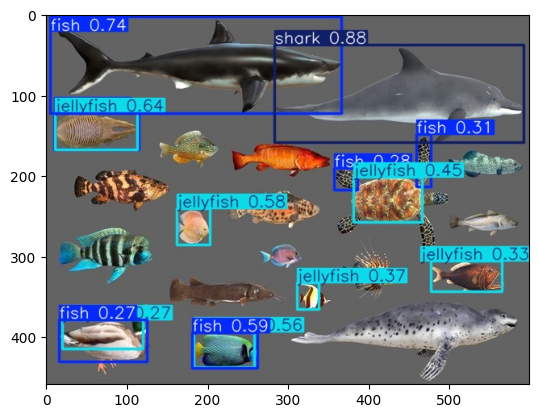

In [8]:
# fine tuning된 새로운 모델로 감지를 원하는 이미지에 대해 검출 시도
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO("/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/runs/detect/train-3/weights/best.pt")

# 사용자가 업로드한 이미지
image_path = "/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/newimg.jpg"

results_pred = model.predict(source=image_path, save=True, imgsz=416)

from pathlib import Path
result_img_path = Path(results_pred[0].save_dir) / Path(image_path).name
print(result_img_path)

img = Image.open(result_img_path)
plt.imshow(img)


In [17]:
# 탐지된 클래스 정보
import numpy as np
from collections import defaultdict     # 기본값이 자동으로 들어가는 자료구조

detected_classes = []
conf_dict = defaultdict(list)

for box in results_pred[0].boxes:
    cls_id = int(box.cls)
    cls_name = model.names[cls_id]
    conf = float(box.conf)
    detected_classes.append(cls_name)
    conf_dict[cls_name].append(conf)


print("탐지된 클래스 전체 : ", detected_classes)
print("고유 클래스 : ", sorted(set(detected_classes)))

# 클래스 별 요약
for cls_name, confs in conf_dict.items():
    print(f" - {cls_name} \t: 갯수={len(confs):.2f}, 평균 신뢰도={np.mean(confs):.3f}")




탐지된 클래스 전체 :  ['shark', 'fish', 'jellyfish', 'fish', 'jellyfish', 'jellyfish', 'fish', 'jellyfish', 'jellyfish', 'jellyfish', 'fish', 'fish', 'fish', 'jellyfish']
고유 클래스 :  ['fish', 'jellyfish', 'shark']
 - shark 	: 갯수=1.00, 평균 신뢰도=0.878
 - fish 	: 갯수=6.00, 평균 신뢰도=0.441
 - jellyfish 	: 갯수=7.00, 평균 신뢰도=0.456
